# Pipeline reproducible y calidad de datos

**Proyecto Final Henry · Dynamo Consultoría & Data Solutions**

Este notebook muestra cómo el proyecto pasa de los CSV crudos de Olist a la comparación de modelos con un solo comando, y documenta la calidad de los datos y las decisiones tomadas.

1. **Configuración**
2. **El pipeline:** qué hace cada paso
3. **Los datos:** la tabla de interacciones
4. **Calidad de datos:** faltantes, outliers y desbalance
5. **Features**
6. **Modelos:** comparación de resultados
7. **Reproducibilidad**
8. **Limitaciones e ideas**
9. **Conclusiones**

**Cómo usarlo:** por defecto lee los resultados guardados en `reports/`, así se ejecuta en segundos. Para recalcular todo desde cero, cambiar `EJECUTAR_PIPELINE = True` en la sección 2 (~7 minutos).


## 1. Configuración


In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.config import INTERACTIONS_PATH, REPORTS_DIR

pd.set_option("display.width", 140)
AZUL, GRIS = "#2a78d6", "#b9b8b2"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.edgecolor": "#888"})
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: c:\Users\denny\proyectos\dynamo-recsys-olist


## 2. El pipeline: qué hace cada paso

Todo el proyecto se ejecuta con un solo comando, `python -m src.pipeline`, que corre estos 5 pasos en orden. Cada paso usa lo que produjo el anterior, por eso el orden importa.

| Paso | Script | Recibe | Produce |
|---|---|---|---|
| 1. Datos crudos | `src/data/download_data.py` | — | 9 CSV de Olist en `data/raw/` |
| 2. Interacciones | `src/data/make_interactions.py` | Los 9 CSV | `data/processed/interactions.parquet` |
| 3. Calidad de datos | `src/data/data_quality.py` | `interactions.parquet` + clientes | `reports/dq_*.csv` |
| 4. Features | `src/data/feature_engineering.py` | `interactions.parquet` | `user_features.parquet`, `product_features.parquet` |
| 5. Modelos | `src/models/train_compare.py` | `interactions.parquet` | `reports/model_comparison.csv` |

**Por qué un script `.py` y no todo en el notebook:** el `.py` se puede automatizar (GitHub Actions, MLflow) y lo pueden importar la API y la demo. Este notebook solo lo ejecuta y muestra sus resultados.

**Dos decisiones de diseño:**
- La calidad de datos (paso 3) va **después** de las interacciones (paso 2), porque necesita `interactions.parquet`.
- Si un script todavía no existe en la rama, el pipeline lo marca como **saltado** y sigue, en lugar de romperse.

In [3]:
# Interruptor: False = usar resultados guardados (segundos) | True = recalcular todo (~7 min)
from datetime import datetime

EJECUTAR_PIPELINE = False

if EJECUTAR_PIPELINE:
    from src import pipeline
    pipeline.main()
else:
    print("Usando los resultados guardados en reports/. Archivos disponibles:\n")
    for archivo in sorted(REPORTS_DIR.glob("*.csv")):
        fecha = datetime.fromtimestamp(archivo.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
        print(f"  {archivo.name:<32} actualizado: {fecha}")

Usando los resultados guardados en reports/. Archivos disponibles:

  baseline_results.csv             actualizado: 2026-10-08 16:33
  dq_cantidades.csv                actualizado: 2026-10-08 16:54
  dq_desbalance.csv                actualizado: 2026-10-08 16:54
  dq_faltantes.csv                 actualizado: 2026-10-08 16:54
  dq_nulos_disfrazados.csv         actualizado: 2026-10-08 16:54
  dq_outliers.csv                  actualizado: 2026-10-08 16:54
  model_comparison.csv             actualizado: 2026-10-08 17:00
  validation_recent_window.csv     actualizado: 2026-10-08 16:56


## 3. Los datos: la tabla de interacciones

El paso 2 une 6 de los 9 CSV de Olist en una sola tabla. **Cada fila es un producto dentro de un pedido:** si un cliente compra 2 unidades del mismo producto en un pedido, es una fila con `quantity = 2`; si vuelve a comprarlo en otro pedido, es otra fila.

In [4]:
df= pd.read_parquet(INTERACTIONS_PATH)

print(f"Filas (producto dentro de un pedido): {len(df):,}")
print(f"Clientes únicos:                      {df['customer_unique_id'].nunique():,}")
print(f"Productos únicos:                     {df['product_id'].nunique():,}")
print(f"Categorías:                           {df['category'].nunique()}")
print(f"Rango de fechas:                      {df['purchase_ts'].min():%Y-%m-%d} a {df['purchase_ts'].max():%Y-%m-%d}")
df.head()

Filas (producto dentro de un pedido): 101,953
Clientes únicos:                      94,983
Productos únicos:                     32,729
Categorías:                           74
Rango de fechas:                      2016-09-04 a 2018-09-03


,order_id,customer_unique_id,product_id,seller_id,purchase_ts,price,freight_value,quantity,review_score,category
0,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,c1488892604e4ba5cff5b4eb4d595400,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,39.99,31.67,1,1.0,furniture_decor
1,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,f293394c72c9b5fafd7023301fc21fc2,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,32.90,31.67,1,1.0,furniture_decor
2,bfbd0f9bdef84302105ad712db648a6c,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-15 12:16:38,44.99,2.83,3,1.0,health_beauty
3,3b697a20d9e427646d92567910af6d57,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,522620dcb18a6b31cd7bdf73665113a9,2016-10-03 09:44:50,29.90,15.56,1,4.0,watches_gifts
4,be5bc2f0da14d8071e2d45451ad119d9,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,f09b760d23495ac9a7e00d29b769007c,2016-10-03 16:56:50,21.90,17.19,1,4.0,sports_leisure


## 4. Calidad de datos

El paso 3 del pipeline (`src/data/data_quality.py`) revisa 5 aspectos y guarda cada resultado en `reports/`. para cada uno se muestra el resultado y la decisión tomada .
**Criterio general:** un valor raro no es necesariamente un error . Antes de borrar o modificar algo, se busca una explicación de negocio.

In [5]:
faltantes= pd.read_csv(REPORTS_DIR / "dq_faltantes.csv")
disfrazados= pd.read_csv(REPORTS_DIR / "dq_nulos_disfrazados.csv")
outliers= pd.read_csv(REPORTS_DIR / "dq_outliers.csv")
cantidades= pd.read_csv(REPORTS_DIR / "dq_cantidades.csv")
desbalance= pd.read_csv(REPORTS_DIR / "dq_desbalance.csv")
print("5 reportes de calidad cargados.")

5 reportes de calidad cargados.


### 4.1 Valores faltantes

In [6]:
faltantes

,columna,nulos,pct_nulos
0,review_score,780,0.77
1,order_id,0,0.00
2,customer_unique_id,0,0.00
3,product_id,0,0.00
4,purchase_ts,0,0.00
5,seller_id,0,0.00
6,price,0,0.00
7,freight_value,0,0.00
8,quantity,0,0.00
9,category,0,0.00


**Resultado:** la única columna con nulos es `review_score`: 780 filas (0,77%), pedidos sin reseña. Coincide con lo que reporta el paso 2.

**Decisión:** se conservan. Un pedido sin reseña sigue siendo una compra válida y no se descarta. Las features de usuario y producto imputan esos nulos con el promedio general.


### 4.2 Nulos disfrazados

`check_missing` indica 0 nulos en `category`, pero el paso 2 rellenó los productos sin categoría con el texto `"unknown"`. El nulo sigue ahí, con otro nombre.

In [7]:
disfrazados

,columna,valor_relleno,filas,pct_filas,productos
0,category,unknown,1446,1.42,600


**Resultado:** 1.446 compras (1,42%) de 600 productos tienen categoría `"unknown"`. Afectan al doble de filas que los nulos reales de `review_score`, así que `check_missing` sola subestimaba el problema.

**Por qué 600 y no 610:** el catálogo tiene 610 productos sin categoría, pero 10 nunca se vendieron en un pedido válido, así que no aparecen en las interacciones.

**Decisión:** se conservan como `"unknown"`. Limitación documentada: para los modelos basados en categoría, esos productos parecen de "la misma categoría" aunque no lo sean.

### 4.3 Outliers en precio y flete (regla IQR)

Regla IQR: es outlier todo valor mayor que `Q3 + 1,5 × (Q3 − Q1)`.

In [8]:
outliers

,columna,q1,q3,limite_sup,n_outliers,pct_outliers,max
0,price,40.00,139.00,287.50,7632,7.49,6735.00
1,freight_value,13.15,21.22,33.32,10624,10.42,409.68


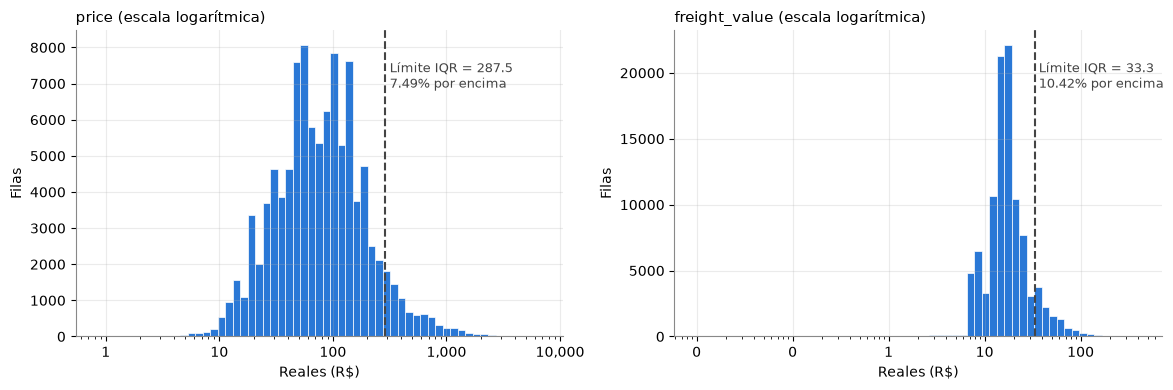

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (_, fila) in zip(axes, outliers.iterrows()):
    col, limite = fila["columna"], fila["limite_sup"]
    valores = df.loc[df[col] > 0, col]          # la escala log no admite ceros
    bins = np.logspace(np.log10(valores.min()), np.log10(valores.max()), 60)
    ax.hist(valores, bins=bins, color=AZUL, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.axvline(limite, color="#444", linestyle="--", linewidth=1.5)
    ax.text(limite * 1.1, ax.get_ylim()[1] * 0.9,
            f"Límite IQR = {limite:,.1f}\n{fila['pct_outliers']}% por encima",
            fontsize=9, color="#444", va="top")
    ax.set_title(f"{col} (escala logarítmica)", loc="left", fontsize=11)
    ax.set_xlabel("Reales (R$)")
    ax.set_ylabel("Filas")
plt.tight_layout()
plt.show()

**Resultado:** la regla marca como outliers al 7,5% de los precios (sobre R$ 287,5) y al 10,4% de los fletes (sobre R$ 33,3). El gráfico muestra que la distribución tiene una **cola larga** que baja de forma continua, sin un grupo separado que indique errores de carga.

**Decisión:** se conservan. La regla IQR sirve para *detectar* valores altos, no para decidir si son errores: supone datos más o menos simétricos, y en e-commerce los precios tienen cola larga. Los precios altos corresponden a productos reales (electrodomésticos, muebles) y los fletes altos a productos grandes o envíos lejanos. Borrar el 10% de las ventas sería perder información real.

**Fletes en cero:** no se muestran en el gráfico (la escala logarítmica no admite ceros). Corresponden a envíos gratis por promoción, no a errores.